# Phase Two: Feature Engineering

In [1]:
import ee


print("Authenticating with Google Earth Engine...")
ee.Authenticate()

print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

In [3]:
from ipywidgets import interact
from IPython.display import display


import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn import linear_model

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from data import indices, load_CHIRPS, load_ERA5, load_S2, utils
from visualisation import index_plotter
from features import engineering

from pygam import LinearGAM, s

importlib.reload(indices)
importlib.reload(load_S2)
importlib.reload(load_ERA5)
importlib.reload(load_CHIRPS)
importlib.reload(utils)
importlib.reload(index_plotter)
importlib.reload(engineering)

<module 'features.engineering' from '/home/luke/projects/phenohmm/src/features/engineering.py'>

## Prepare DataFrames

In [4]:
region = utils.get_region()
i_date = "2021-01-01"
f_date = "2024-12-31"

In [5]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])
spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])
grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

In [6]:
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation
0,2018-01-07,0.454175,0.017789,0.154850,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,0.270322,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000
1,2018-03-03,0.629801,0.031419,0.310717,0.025493,0.438958,0.033150,0.275499,0.294964,0.281848,0.269882,296.319232,295.264591,293.797097,292.708587,293.174303,284.739623,300.874879,2.653625e+07,5.928807
2,2018-06-01,0.330054,0.013942,0.073200,0.005519,0.220654,0.008582,0.387392,0.309780,0.338261,0.271122,283.614288,284.567219,286.777798,290.473939,281.743066,275.021431,288.422674,1.504906e+07,0.000000
3,2018-06-06,0.289118,0.015937,-0.017437,0.002453,0.180388,0.010207,0.336953,0.310565,0.336209,0.271163,281.924616,282.769941,285.820755,290.178382,280.752142,274.098569,288.798194,1.452415e+07,0.000000
4,2018-06-11,0.264834,0.027659,-0.018403,0.011886,0.172670,0.016877,0.307676,0.305746,0.333914,0.271199,282.930785,283.265651,285.249282,289.847651,281.838309,276.769477,289.060574,1.396338e+07,0.000000


---

## Growing Degree Days

GDDs are a heuristic used to measure heat accumulation to predict plant development rates. If the crops aren't heavily stressed by other anomalous environmental factors, the development rate from emergence to maturity depends on daily temperature. The variant we will use is:

$$GDD=\text{max}\left\{\frac{T_\text{max}+T_\text{min}}{2}-T_\text{base}, 0\right\}$$

Corn typically has 800 to 2700 GDD to crop maturity, with a recommended baseline of 10 °C.

In [7]:
def gdd(row):
    t_base = 10
    
    t_max = row["temperature_2m_max"] - 273.15
    t_min = row["temperature_2m_min"] - 273.15

    gdd = (t_max + t_min) / 2 - t_base
    
    if gdd > 30:
        return 30
        
    return max(gdd, 0)

In [8]:
non_spectral_df["GDD"] = non_spectral_df.apply(gdd, axis=1)
non_spectral_df["GDD"].head()

0    10.006207
1     7.404952
2     7.165753
3     8.108309
4    10.420760
Name: GDD, dtype: float64

---

## Growth Stages

In the feature engineering chapters to follow, we will see that the relative growth stages of maize plays an integral role in defining the influence and interpretation of many of the environmental variables in our dataset. The challenge in an unsupervised learning problem like this is the fact that we don't have access to labels detailing the growth stages of the crop, so it takes some creativity to approximately classify where in the process our crop field is. 

Maize growth is divided into two main categories, **Vegetative (V)** and **Reproductive (R)**. The vegatative ranking is determined by the amount of visible collars on the plant. 

<img src="assets/maize_collars.jpg" width="350">

The plants grow up to a V18 or V21 stage, where-after it goes into a reproductive stage and loses its greenery. 

<img src="assets/V_n_R.jpg" width="500">



### Introducing NDVI


Why is all this important? For the simple reason that one of our spectral indices, NDVI, is as such a measurement of the "greenery" of the maize crops. More concretely, a higher NDVI tells us that the vegatation in the area under consideration reflects more near-infrared and green light as compared to other wave-lengths, but absorbs more blue and red. The higher the NDVI, the healthier and more green is the crop. In other words, as greenery increases starting from planting season, the average NDVI graph will give us a good indication of the growth stages of the maize.


$$\text{NDVI}=\frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

In [9]:
plot_df = master_df[master_df["Timestamp"] < pd.to_datetime("2026-01-01")].copy()
plot_df = plot_df.sort_values("Timestamp")
plot_df["doy"] = plot_df["Timestamp"].dt.dayofyear

#jul1_doy = pd.Timestamp("2021-07-01").dayofyear
#plot_df["doy"] = ((plot_df["Timestamp"].dt.dayofyear - jul1_doy) % 365) + 1


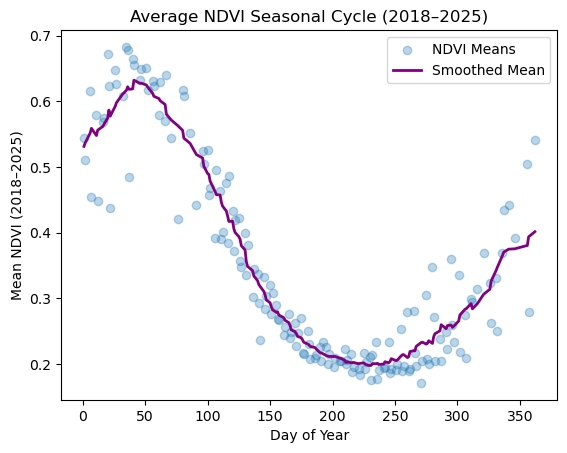

In [10]:

clim = plot_df.groupby("doy")["NDVI_mean"].mean().sort_index()
clim_smooth = clim.rolling(window=14, center=True, min_periods=1).mean()

plt.figure()
plt.scatter(clim.index, clim.values, alpha=0.3, label="NDVI Means")
plt.plot(clim_smooth.index, clim_smooth.values, linewidth=2, label="Smoothed Mean", color="purple")
plt.xlabel("Day of Year")
plt.ylabel("Mean NDVI (2018–2025)")
plt.title("Average NDVI Seasonal Cycle (2018–2025)")
plt.legend()
plt.show()

While the above graph certainly gives us a good picture of the **average** cycle of NDVI throughout the year, there are a few issues. First, this is purely the mean of means. There is a large discontinuity between the two end-points of the graph and therefore it is not cyclic. It is by no means a robust estimator of the NDVI cycle and therefore its residuals and derivatives should not be trusted for inference. Crucially, all these issues can mostly be solved by fitting a **Generalised Additive Model** (GAM) to our NDVI data. 

We first shift the DOY axis so that the growing season does not "carry over" to the following year. This will provide is with better behaviour from the cyclic spline. 

In [11]:
shift = pd.Timestamp("2019-08-01").dayofyear

def shift_doy(x):
    shifted_doy = ((x - shift) % 365) + 1
    return shifted_doy

def inv_shift_doy(x):
    inv_shifted_doy = (x + shift - 1) % 365
    return inv_shifted_doy

In [12]:
# Shift data to approximately before the start of the growing steason
shifted_doy = ((plot_df["Timestamp"].dt.dayofyear - shift) % 365) + 1
plot_df["shifted_doy"] = shifted_doy

doys = np.arange(1, 366)
agr_doys = ((doys - shift) % 365) + 1

# Define x-ticks for shifted axis
x_ticks = np.arange(1, 366, 30)
x_labels = ((x_ticks + shift - 1) % 365) + 1

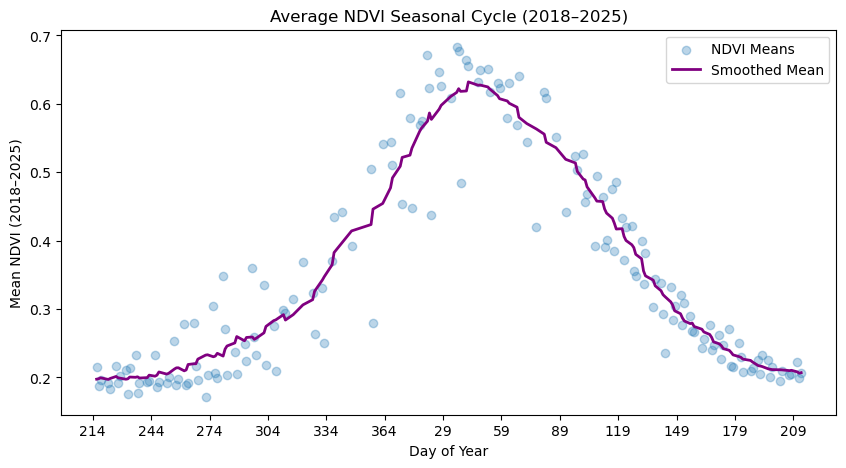

In [13]:

clim = plot_df.groupby("shifted_doy")["NDVI_mean"].mean().sort_index()
clim_smooth = clim.rolling(window=14, center=True, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.scatter(clim.index, clim.values, alpha=0.3, label="NDVI Means")
plt.plot(clim_smooth.index, clim_smooth.values, linewidth=2, label="Smoothed Mean", color="purple")

plt.xticks(ticks = x_ticks, labels=x_labels)

plt.xlabel("Day of Year")
plt.ylabel("Mean NDVI (2018–2025)")
plt.title("Average NDVI Seasonal Cycle (2018–2025)")
plt.legend()
plt.show()

This shift is not at all aligned with our true start-of-season, but it does give us a nice bell curve for when fitting our GAM.

#### Seasonal Cyclic GAM

We will make use of a cyclic GAM fit on NDVI against DOY. The cyclic constraint of the cubic spline ensures our predicted curve and its derivatives match at the start and end of the year. This is _not_ a model intended for prediction. Instead it is a model of climatology - an "average" movement of NDVI over all the DOY's of the dataset. 

In [14]:
X = plot_df["shifted_doy"].values.reshape(-1, 1)
y = plot_df["NDVI_mean"].values

lams = np.logspace(-6, 6, 25)
#n_splines = [10, 20, 30, 50]
gam = LinearGAM(s(0, basis="cp", n_splines=30))
gam.gridsearch(X, y, lam=lams)


100% (25 of 25) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

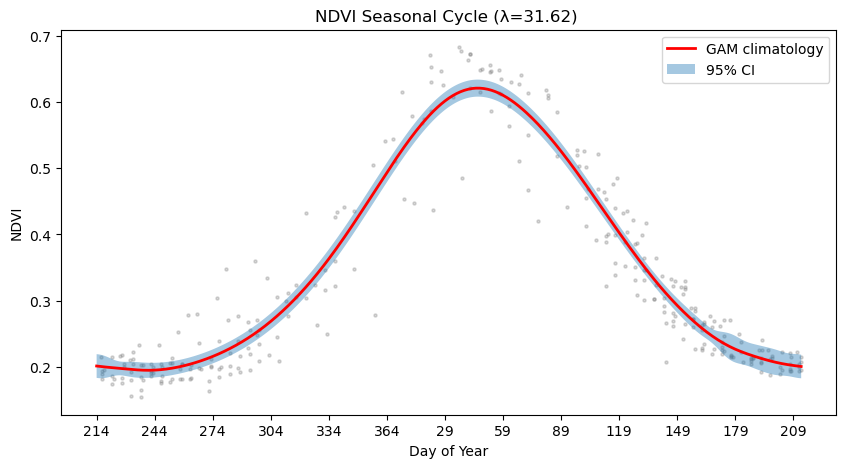

In [15]:
X_pred = doys.reshape(-1, 1)
pred = gam.predict(X_pred)
ci = gam.confidence_intervals(X_pred, width=0.95)

plt.figure(figsize=(10, 5))
plt.title(f"NDVI Seasonal Cycle (λ={gam.terms[0].lam[0]:.2f}) ")

plt.scatter(x = plot_df["shifted_doy"], y=plot_df["NDVI_mean"], alpha=0.3, s=5, color='grey')
plt.plot(X_pred, pred, linewidth=2, color="red", label="GAM climatology")
plt.fill_between(X_pred.flatten(), ci[:, 0], ci[:, 1], alpha=0.4, label="95% CI")

plt.ylabel("NDVI")

plt.xticks(x_ticks, labels=x_labels)
plt.xlabel("Day of Year")

plt.legend()
plt.show()

The function under consideration is $$NDVI_i = f(\text{DOY}_i)+\epsilon_i$$
where the GAM is estimating $f(\text{DOY}_i)$ i.e. estimating the average NDVI seasonal cycle as a function of the day of year (DOY). This gives us an interpolated seasonal curve, with the ability to find $f'(d)$ which will give us the average green-up rate of the crops.

In [16]:
dy_dx = np.gradient(pred, doys)
d2y_dx2 = np.gradient(dy_dx, doys)

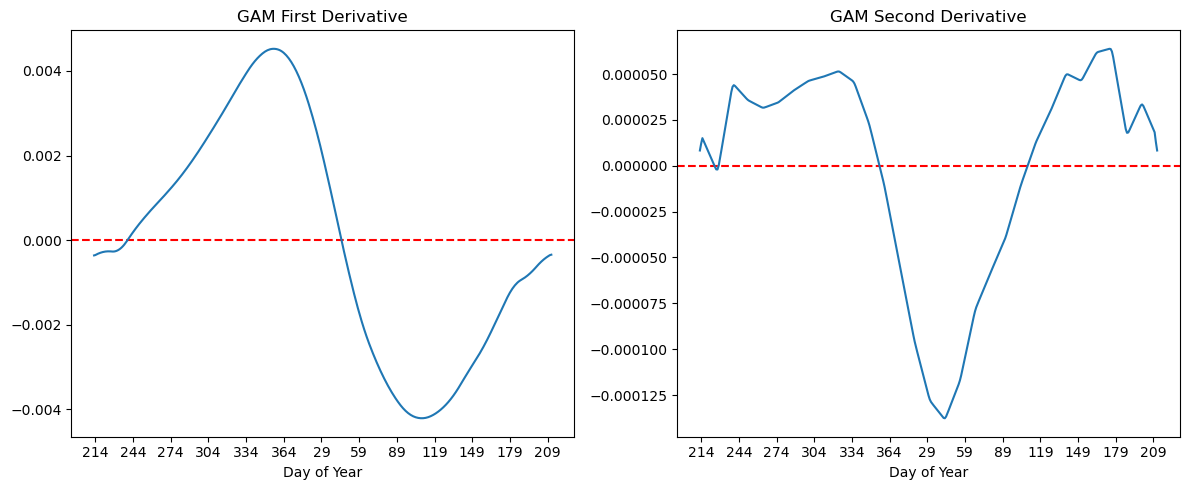

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
#plt.figure(figsize=(10,5))
ax[0].set_title("GAM First Derivative")
ax[0].axhline(y=0, color='red', linestyle='--')
ax[0].set_xticks(x_ticks, labels=x_labels)
ax[0].set_xlabel("Day of Year")
ax[0].plot(dy_dx)

ax[1].set_title("GAM Second Derivative")
ax[1].axhline(y=0, color='red', linestyle='--')
ax[1].set_xticks(x_ticks, labels=x_labels)
ax[1].set_xlabel("Day of Year")
ax[1].plot(d2y_dx2)

plt.tight_layout()
plt.show()

The `LinearGAM` has a first derivative representing the change in NDVI per individual day, while the second derivative describes the relative acceleration/deceleration of greening within the crops.

- The zero crossing of the first derivative ($f'(x)=0$) represents the absolute minimum of the vegetative cycle. This is the moment the ecosystem transititions from dormancy to growth.
- The second derivative $f''(x)$ has two peaks. The first peak can be interpreted as the moment the canopy developments hits its maximum acceleration. The second peak is the "leveling off" after the end-of-season NDVI drop.

### Start-of-Season

It is not difficult to see that our average **Start of Season** DOY will almost certainly be between the zero-crossing of the first derivative and the first peak of the second derivative. To find this DOY, we have to:
1. Find the zero crossing (from negative to positive) in the $dy/dx$ curve,
2. Find the peak of the second derivative _before the winter season_.

In [18]:
num_doys = len(dy_dx)

In [19]:
# We first find a search window for the second derivative peak
decay_start = 0
for i in range(num_doys - 1):
    if dy_dx[i] > 0 and dy_dx[i+1] < 0:
        decay_start = inv_shift_doy(i)

print(f"NDVI starts decreasing on {decay_start}")

NDVI starts decreasing on 43


In [20]:
zero_crossing_doy = 0
first_peak_doy = 0
max_d2y = -np.inf

for i in range(num_doys - 1):
    shifted_i = inv_shift_doy(i)
    
    if dy_dx[i] < 0 and dy_dx[i+1] > 0:
            zero_crossing = shifted_i
    if shifted_i > inv_shift_doy(1) or shifted_i < decay_start:
        if d2y_dx2[i] > max_d2y:
            max_d2y = d2y_dx2[i]
            first_peak = shifted_i

print(f"Transition from dormancy to growth starts at {zero_crossing}")
print(f"Maximum acceleration of green-up is at {first_peak}")

Transition from dormancy to growth starts at 238
Maximum acceleration of green-up is at 322


### End-of-Season

Now to define our **End of Season**, we follow similar logic. The lowest negative value of $f'(x)$ is the point where the canopy is losing greenery at the fastest rate. The local minimum of $f''(x)$ represents the moment the crop crash hits its maximum downward acceleration, i.e. the leaves are browning at a faster rate each day. The decay has to stabilise at some point - therefore the second peak of $f''(x)$ is the "dormancy date" - the seasonal change has finished and the field remains dormant. This will be our EoS.

In [21]:
second_peak = 0
max_d2y = -np.inf

for i in range(num_doys - 1):
    shifted_i = inv_shift_doy(i)

    if shifted_i > decay_start and shifted_i < inv_shift_doy(1):
        if d2y_dx2[i] > max_d2y:
            max_d2y = d2y_dx2[i]
            second_peak = shifted_i

print(f"Day dormancy is reached is {second_peak}")

Day dormancy is reached is 173


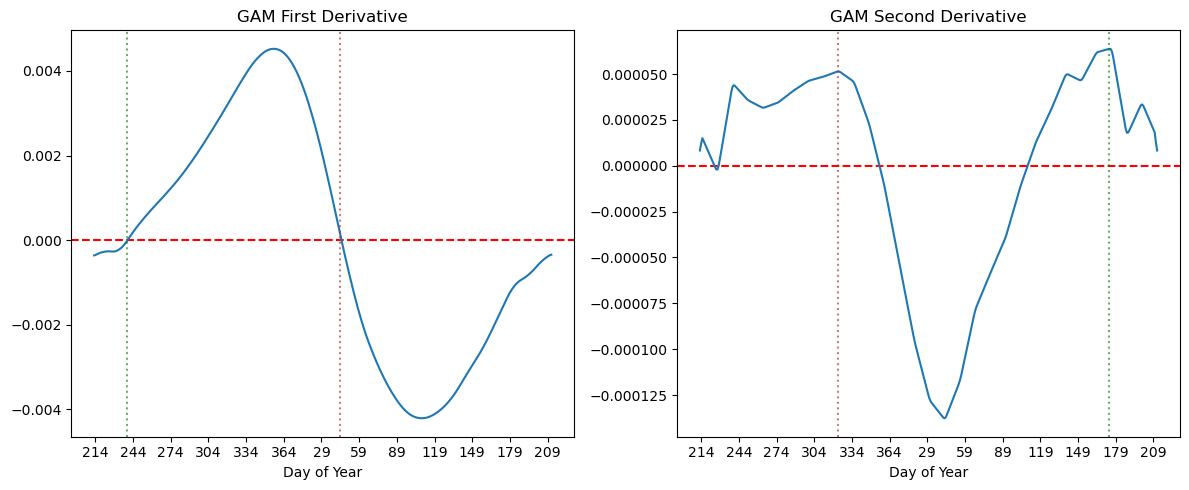

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
#plt.figure(figsize=(10,5))
ax[0].set_title("GAM First Derivative")
ax[0].axhline(y=0, color='red', linestyle='--')
ax[0].set_xticks(x_ticks, labels=x_labels)
ax[0].set_xlabel("Day of Year")
ax[0].plot(dy_dx)
ax[0].axvline(x = shift_doy(decay_start), linestyle=':', alpha=0.6, color="brown")
ax[0].axvline(x = shift_doy(zero_crossing), linestyle=':', alpha=0.6, color="green")

ax[1].set_title("GAM Second Derivative")
ax[1].axhline(y=0, color='red', linestyle='--')
ax[1].set_xticks(x_ticks, labels=x_labels)
ax[1].set_xlabel("Day of Year")
ax[1].plot(d2y_dx2)
ax[1].axvline(x = shift_doy(second_peak), linestyle=":", alpha=0.6, color="green")
ax[1].axvline(x = shift_doy(first_peak), linestyle=":", alpha=0.6, color="brown")

plt.tight_layout()
plt.show()

In summary, we derived the following points from the GAM:
$$\begin{align} \text{Start of Season }&: SOS_t \in [238, 322] \\ \text{End of Season }&: EOS_t = 173\end{align}$$

### Cummulative GDD

We now start the process for the feature `Cumulative_GDD`. This feature is zero throughout the whole season *until* the moment growing season starts. In the absense of extreme environmental anomalies, the maturity of the crops can in essence be seen as a function of daily temperature. The `Cumulative_GDD` will therefore give us a good indication of the current growing stage of the crop. Note that this features resets to 0 each year when the growing season has ended.

How do we define when the cumulation starts and ends for each year? We use the **zero-crossing** and point of dormancy we found using our cyclic GAM. 

We will be using the `non_spectral_df` dataset for this, since GDD does not need NDVI to be calculated, so we can use all daily observations from beginning 2018 to end 2025. 


In [23]:
sos = 300 # start of season
eos = 173  # end of season

# Change the global shift period
shift = sos

shifted_sos = shift_doy(sos)
shifted_eos = shift_doy(eos)

x_ticks = np.arange(1, 366, 30)
x_labels = inv_shift_doy(x_ticks) + 1


In [24]:
gdd_df = non_spectral_df.copy()
gdd_df["doy"] = gdd_df["Timestamp"].dt.dayofyear
gdd_df["year"] = gdd_df["Timestamp"].dt.year
gdd_df["shifted_doy"] = gdd_df["doy"].apply(shift_doy)

years = np.unique(gdd_df["year"])

Our first important step for this process is to account for the fact that the full growth season does not take place within a single calendar year, so `.groupby()` breaks a season in half. This issue extends to another issue in that we have multiple years' worth of data. Without a "pointer" to a specific growth season/year, we will just be summing all the multi-year GDD's corresponding to some $DOY$. 

Therefore we define a new feature called `Ag_year`, i.e. the agricultural year under consideration spanning from the start of the growing season until after the harvest. 

To see how `Ag_year` works, consider some arbitrary DOY $t$ with corresponding year $y$. 
$$\therefore \text{AG-year}(t, y) = \begin{cases} y & \text{if } t \ge SOS \\ y-1 & \text{otherwise} \end{cases}$$

We must also account for the fact that our end-of-season cutoff is $t \in [SOS, \ EOS]$. We create a variable called `in_season` for this, where 
$$
\text{in\_season}(t) = 
\begin{cases} 
1 & \text{if } SOS \le t \le EOS \\
0 & \text{otherwise} 
\end{cases}
$$

In [25]:
gdd_df["Ag_year"] = np.where(gdd_df["doy"] >= sos, gdd_df["year"], gdd_df["year"] - 1)    
gdd_df["in_season"] = (
    (gdd_df["shifted_doy"] >= shifted_sos) &
    (gdd_df["shifted_doy"] <= shifted_eos)
).astype(int)
gdd_df = gdd_df.sort_values(by=["Ag_year", "shifted_doy"])


Finally, the total sum feature can be created.

In [26]:
# Only sum GDD observations that are in season
gdd_df["GDD_in_season"] = gdd_df["GDD"].where(gdd_df["in_season"] == 1, 0)

gdd_df["cumulative_GDD"] = gdd_df.groupby("Ag_year")["GDD_in_season"].cumsum()
gdd_df["cumulative_GDD"] = gdd_df["cumulative_GDD"].where(gdd_df["in_season"] == 1, 0)

We can visualise the cumulative GDD along with NDVI to check if we have structured everything correctly. Let's consider only 2024 for this example.

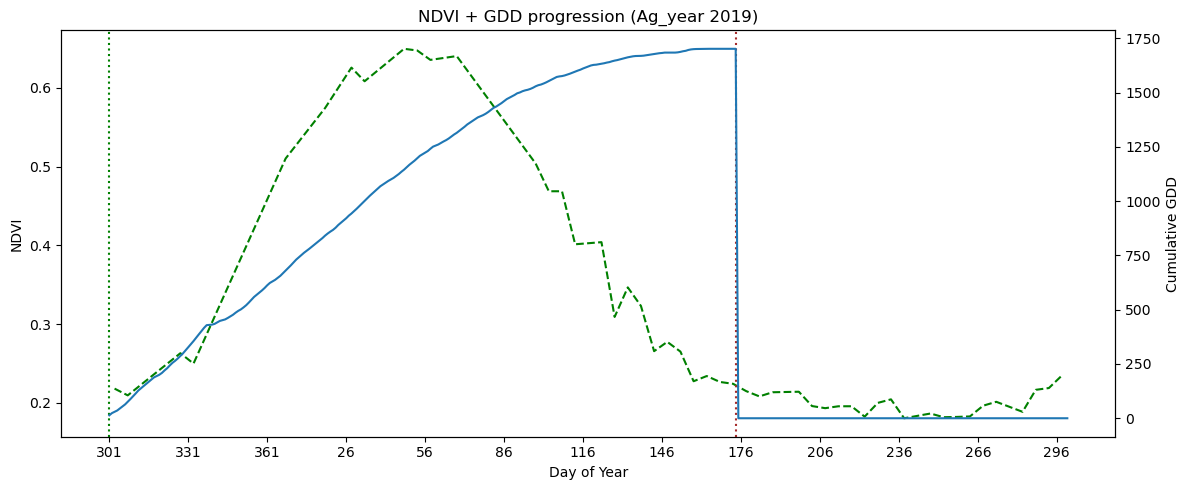

In [27]:
year = 2019

dfy = gdd_df[gdd_df["Ag_year"] == year]
ndvi = utils.merge_with_master(grouped_spectral_df, gdd_df)
ndvi_y = ndvi[ndvi["Ag_year"] == year]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(ndvi_y["shifted_doy"], ndvi_y["NDVI_mean"], color="green", linestyle="--")
ax1.set_xticks(x_ticks, labels=x_labels)
ax1.set_xlabel("Day of Year")
ax1.set_ylabel("NDVI")
ax1.axvline(x=shift_doy(sos), color='green', linestyle=':', label="Start of Season")
ax1.axvline(x=shifted_eos, color='brown', linestyle=':', label="Max Senescence")

ax2 = ax1.twinx()
ax2.set_ylabel("Cumulative GDD")
ax2.plot(dfy["shifted_doy"], dfy["cumulative_GDD"], linestyle="solid")
plt.title(f"NDVI + GDD progression (Ag_year {year})")
fig.tight_layout()
plt.show()

### Labeling Growth Stages using GDD

https://www.cropscience.bayer.us/articles/bayer/corn-growth-stages-and-gdu-requirements

Using the resource above, we define the labels for the vegetative stages corresponding to the cumulative GDD's feature.

| **Corn Growth Stage** | **Fahrenheit GDD** | **Celsius GDD** |
|-----------------------|--------------------|-----------------|
| VE (Emergence)        | 100 – 120          | 56 – 67         |
| V2                    | 200                | 111             |
| V4                    | 360                | 200             |
| V6                    | 520                | 289             |
| V8 to V9              | 680 – 760          | 378 – 422       |
| V12                   | 900                | 500             |
| V13                   | 955                | 531             |
| V16                   | 1,150              | 639             |
| V17+                  | 1,300              | 722             |
| VT (Tasseling)        | 1,350              | 750             |
| R1 – Silking          | 1,500              | 833             |
| R2 – Blister          | 1,700              | 944             |
| R3 – Milk             | 1,875              | 1,042           |
| R4 – Dough            | 1,950              | 1,083           |
| R5 – Dent             | 2,300              | 1,278           |
| R6 – Black Layer      | 2,700              | 1,500           |


In [28]:
stages = [
    "R6", "R5", "R4", "R3", "R2", "R1", 
    "VT", "V16+", "V13", "V12", "V8-V9", "V6", "V4", "V2", "VE", "SoS"
]

conditions = [
    gdd_df["cumulative_GDD"] >= 1500, 
    gdd_df["cumulative_GDD"] >= 1278,  
    gdd_df["cumulative_GDD"] >= 1083,  
    gdd_df["cumulative_GDD"] >= 1042,  
    gdd_df["cumulative_GDD"] >= 944,   
    gdd_df["cumulative_GDD"] >= 833,   
    gdd_df["cumulative_GDD"] >= 750,   
    gdd_df["cumulative_GDD"] >= 639,   
    gdd_df["cumulative_GDD"] >= 531,  
    gdd_df["cumulative_GDD"] >= 500,   
    gdd_df["cumulative_GDD"] >= 378,   
    gdd_df["cumulative_GDD"] >= 289,   
    gdd_df["cumulative_GDD"] >= 200,   
    gdd_df["cumulative_GDD"] >= 111,   
    gdd_df["cumulative_GDD"] >= 56,    
    gdd_df["cumulative_GDD"] > 0       
]

gdd_df["Growth_Stage"] = np.select(conditions, stages, default='Off-Season')
gdd_df["Growth_Stage"] = np.where(gdd_df["in_season"] == 0, "Off-Season", gdd_df["Growth_Stage"])
gdd_df.head()

,Timestamp,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,...,precipitation,GDD,doy,year,shifted_doy,Ag_year,in_season,GDD_in_season,cumulative_GDD,Growth_Stage
0,2018-01-01,0.371225,0.394800,0.302474,0.270380,294.466628,294.026363,293.144239,290.955942,293.314439,...,0.000000,10.006207,1,2018,67,2017,1,10.006207,10.006207,SoS
1,2018-01-02,0.347555,0.379907,0.302010,0.270373,293.848773,293.884632,293.162249,290.987094,289.883795,...,0.000000,7.404952,2,2018,68,2017,1,7.404952,17.411159,SoS
2,2018-01-03,0.330737,0.367946,0.301465,0.270366,293.911082,293.727159,293.150462,291.017846,290.475579,...,0.000000,7.165753,3,2018,69,2017,1,7.165753,24.576912,SoS
3,2018-01-04,0.315402,0.356416,0.300741,0.270358,294.503247,293.925443,293.141661,291.047929,291.254956,...,2.618651,8.108309,4,2018,70,2017,1,8.108309,32.685221,SoS
4,2018-01-05,0.302094,0.344448,0.299777,0.270349,295.542367,294.539959,293.180125,291.077664,293.653434,...,1.835338,10.420760,5,2018,71,2017,1,10.420760,43.105980,SoS


To illustrate how we label  the growth stages for different years, we use the interaction widget. Each step in the widget plots a graph for the corresponding agricultural year, showing the  NDVI, our approximate growth labels, and the approximate cummulative GDD.

In [29]:
def plot_growth(year):
    dfy = gdd_df[gdd_df["Ag_year"] == year]
    ndvi = utils.merge_with_master(grouped_spectral_df, gdd_df)
    ndvi_y = ndvi[ndvi["Ag_year"] == year]
    
    # summary dataframe for growth stage transitions
    transition_dates = dfy.groupby("Growth_Stage")["shifted_doy"].min().reset_index()
    transition_dates = transition_dates.sort_values(by="shifted_doy")
    
    stage_positions = transition_dates["shifted_doy"].tolist()
    stage_labels = transition_dates["Growth_Stage"].tolist()
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax1.plot(ndvi_y["shifted_doy"], ndvi_y["NDVI_mean"], color="green")
    ax1.set_xticks(x_ticks, labels=x_labels)
    ax1.set_xlabel("Day of Year")
    ax1.set_ylabel("NDVI")
    
    ax1.vlines(x=stage_positions, ymin=0, ymax=1, linestyle="--", color="blue", alpha=0.3)
    ax_top = ax1.twiny()
    ax_top.set_xlim(ax1.get_xlim())
    ax_top.set_xticks(stage_positions)
    ax_top.set_xticklabels(stage_labels, rotation=90, ha="left", fontweight="bold", color="black", fontsize=6)
    
        
    ax2 = ax1.twinx()
    ax2.set_ylabel("Cumulative GDD")
    ax2.plot(dfy["shifted_doy"], dfy["cumulative_GDD"], lw=2, color="grey")
    plt.title(f"NDVI + GDD progression (Ag_year {year}), with Growth Labels")
    fig.tight_layout()
    plt.show()

interact(plot_growth, year=(2019, 2024, 1));

interactive(children=(IntSlider(value=2021, description='year', max=2024, min=2019), Output()), _dom_classes=(…

In [30]:
engineered_df = gdd_df.copy()

---

## Soil Layers

Maize crops are deep-rooted - the bulk of functional roots is not at maximum depth. It typically remains in the upper profile, i.e. 0-30cm, with depths exceeding 120cm important during _drought_ periods. 


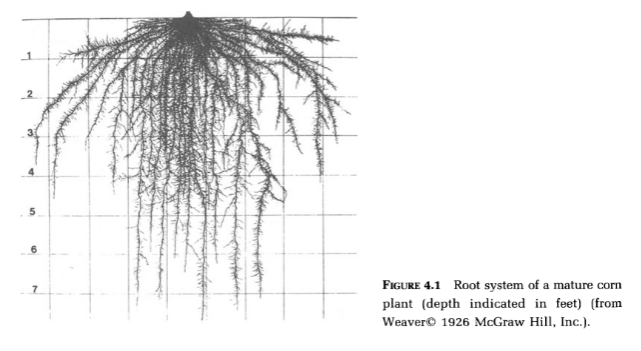

https://link.springer.com/chapter/10.1007/978-1-4612-2694-9_4 

The ERA5 dataset provides us with 4 layers of soil temperature and volumetric water layers. 


| Band Name                     | Unit            | Description                                                                                                                                                                                                                                                                                                                |   |
|-------------------------------|-----------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---|
| soil_temperature_level_1      | K               | Temperature of the soil in layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. Soil temperature is set at the middle of each layer, and heat transfer is calculated at the interfaces between them. It is assumed that there is no heat transfer out of the bottom of the lowest layer. |   |
| soil_temperature_level_2      | K               | Temperature of the soil in layer 2 (7-28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |
| soil_temperature_level_3      | K               | Temperature of the soil in layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                 |   |
| soil_temperature_level_4      | K               | Temperature of the soil in layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                |   |
| volumetric_soil_water_layer_1 | Volume fraction | Volume of water in soil layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. The volumetric soil water is associated with the soil texture (or classification), soil depth, and the underlying groundwater level.                                                                        |   |
| volumetric_soil_water_layer_2 | Volume fraction | Volume of water in soil layer 2 (7 -28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                     |   |
| volumetric_soil_water_layer_3 | Volume fraction | Volume of water in soil layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                    |   |
| volumetric_soil_water_layer_4 | Volume fraction | Volume of water in soil layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |





Naturally considering these as predictors for any model introduces a significant amount of multicolinearity. One might think that dimensionality reduction would be a valid approach to address this issue, however there is a caveat - a climate shock will not have a noteworthy influence on the deep layers in a similar way that it may have on the volatile shallow levels. We must avoid a situation where these deeper layers are used mathematical anchors such  that a large change in the shallow layers will be circumvented by an insignifcant change in the deeper layers. 


### Volumetric Soil Water Layer

As stated above, the deeper layers are typically not the most important when it comes to the maize's health. This leads us to two potential paths forward:

1. **Root weighted averaging depending on growth stage**: A maize plant in its early growth stages will not have a penetrating root system at 180cm, but a mature maize plant will. We therefore introduce as features **root-zone soil moisture** ($SM_{e}$, $SM_m$, $SM_{M}$) for the *early* ($V_E-V_6$ ), *median* ($V_6-V_8$) and *mature* ($V_{12}-V_T$) **vegetation** stages of the crop, respectively. We also define $SM_{R1} - SM_{R6}$ for the **reproductive** stages of the crop.


3. _Truncated_ or _Split-depth_ **Principal Component Analysis**: Instead of running one global PCA on all 4 layers, we split layers 1 and 2 from 3 and 4, and project each of these down to their first direction of maximum variance.




In [31]:
prefix = "volumetric_soil_water_layer"
layers = range(1, 5)
vw_df = engineered_df[[f"{prefix}_{l}" for l in layers]].copy()
vw_df[["Growth_Stage", "shifted_doy", "Timestamp"]] = engineered_df[["Growth_Stage", "shifted_doy", "Timestamp"]].copy()
vw_df.head()

,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,Growth_Stage,shifted_doy,Timestamp
0,0.371225,0.394800,0.302474,0.270380,SoS,67,2018-01-01
1,0.347555,0.379907,0.302010,0.270373,SoS,68,2018-01-02
2,0.330737,0.367946,0.301465,0.270366,SoS,69,2018-01-03
3,0.315402,0.356416,0.300741,0.270358,SoS,70,2018-01-04
4,0.302094,0.344448,0.299777,0.270349,SoS,71,2018-01-05


#### 1. Root-weighted averaging

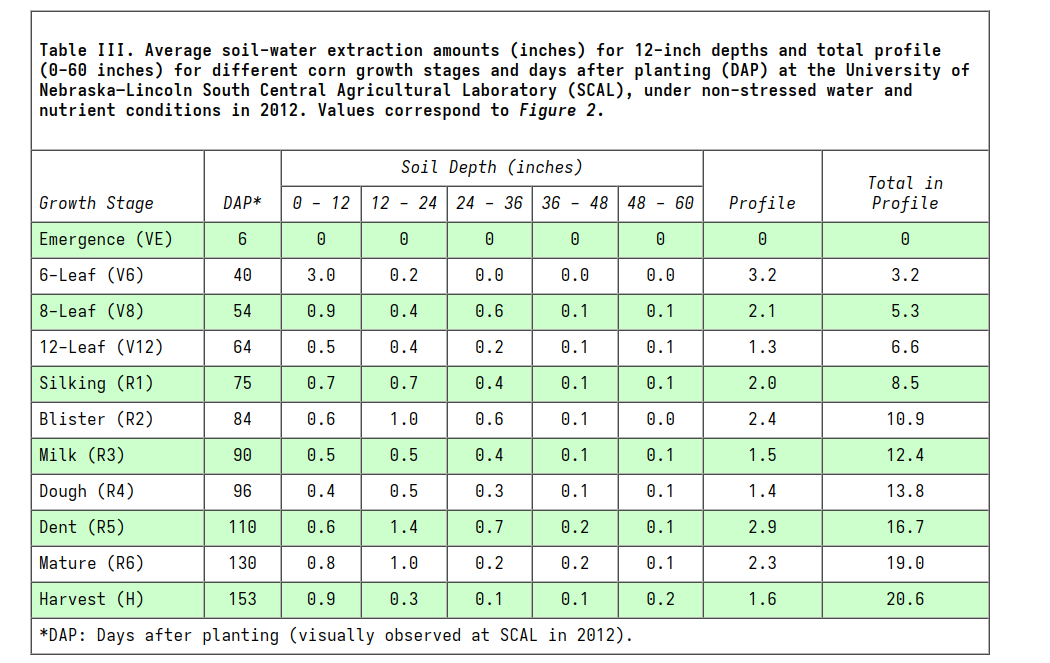

https://extensionpubs.unl.edu/publication/g2245/2014/html/view

The above table gives us the average soil-water extraction amounts for different corn growth stages in a Silt-Loam Soil (provided by SCAL). We will use the proportion of water extracted at each soil depth as the estimate of the weight corresponding to our ERA5 soil layer. 

We form the linear combinations for the **vegetative** stages:
$$\begin{align}
SM_e &= 0.9375(SM_{0-28})+0.0625(SM_{28-100}) \\
SM_m &= 0.4285(SM_{0-28} + 0.4762(SM_{28-100}) + 0.0953(SM_{100-289})) \\
SM_M &= 0.3846(SM_{0-28}) + 0.4615(SM_{28-100}) + 0.1538(SM_{100-289})
\end{align}$$

And the linear combinations for the **reproductive** stages:
$$\begin{align}
SM_{R1} &= 0.3500(SM_{0-28}) + 0.5500(SM_{28-100}) + 0.1000(SM_{100-289}) \\ 
SM_{R2} &= 0.2500(SM_{0-28}) + 0.6667(SM_{28-100}) + 0.0417(SM_{100-289})\\ 
SM_{R3} &= 0.3333(SM_{0-28}) + 0.6000(SM_{28-100}) + 0.1333(SM_{100-289})\\ 
SM_{R4} &= 0.2857(SM_{0-28}) + 0.5714(SM_{28-100}) + 0.1429(SM_{100-289})\\ 
SM_{R5} &= 0.2069(SM_{0-28}) + 0.7241(SM_{28-100}) + 0.1034(SM_{100-289})\\ 
SM_{R6} &= 0.3478(SM_{0-28}) + 0.5217(SM_{28-100}) + 0.1304(SM_{100-289})
\end{align}$$


In [32]:
def root_weight_average(row):
    stages = [
        "R6", "R5", "R4", "R3", "R2", "R1", 
        "VT", "V16+", "V13", "V12", "V8-V9", "V6", "V4", "V2", "VE", "SoS"
    ]
    
    prefix = "volumetric_soil_water_layer"
    layers = range(1, 5)
    if row["Growth_Stage"] == "Off-Season":
        return 0
    
    current_label_i = stages.index(row["Growth_Stage"])
    soil_layers = row[[f"{prefix}_{l}" for l in layers]]

    early_weights = [0.9375/2, 0.9375/2, 0.0625, 0]
    median_weights = [0.4285/2, 0.4285/2, 0.4762, 0.0953]
    mature_weights = [0.3846/2, 0.3846/2, 0.4615, 0.1538]

    R1_weights = [0.3500/2, 0.3500/2, 0.5500, 0.1000]
    R2_weights = [0.2500/2, 0.2500/2, 0.6667, 0.0417]
    R3_weights = [0.3333/2, 0.3333/2, 0.6000, 0.1333]
    R4_weights = [0.2857/2, 0.2857/2, 0.5714, 0.1429]
    R5_weights = [0.2069/2, 0.2069/2, 0.7241, 0.1034]
    R6_weights = [0.3478/2, 0.3478/2, 0.5217, 0.1304]
    R_weights = np.array([R6_weights, R5_weights, R4_weights, R3_weights, R2_weights, R1_weights])

    early_start = stages.index("VE")
    early_cutoff = stages.index("V6")
    median_cutoff = stages.index("V8-V9")
    mature_cutoff = stages.index("VT")

    soil_moisture = 0
    
    for i, v in enumerate(soil_layers):
        if current_label_i <= early_start and current_label_i >= early_cutoff:
            soil_moisture += early_weights[i] * v
        elif current_label_i < early_cutoff and current_label_i >= median_cutoff:
            soil_moisture += median_weights[i] * v
        elif current_label_i < median_cutoff and current_label_i >= mature_cutoff:
            soil_moisture += mature_weights[i] * v
        elif current_label_i < mature_cutoff:
            soil_moisture += R_weights[current_label_i, i] * v
            
    return soil_moisture
        

In [33]:
vw_df["root_weighted_soil_moisture"] = vw_df.apply(root_weight_average, axis=1)
vw_df[vw_df["Growth_Stage"] == "R1"].head()

,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,Growth_Stage,shifted_doy,Timestamp,root_weighted_soil_moisture
95,0.454092,0.459419,0.364031,0.270056,R1,162,2018-04-06,0.387087
96,0.436187,0.445725,0.365237,0.270084,R1,163,2018-04-07,0.382223
97,0.429696,0.435692,0.365699,0.270113,R1,164,2018-04-08,0.379589
98,0.435021,0.429892,0.366039,0.270143,R1,165,2018-04-09,0.379696
99,0.447270,0.428649,0.366292,0.270174,R1,166,2018-04-10,0.381764


In [34]:
engineered_df["root_weighted_soil_moisture"] = vw_df["root_weighted_soil_moisture"].copy()

#### 2. Principal Component Analysis

Our first approach to PCA is a full fit on all 4 water layers. In essence, we are finding the principal directions of the soil moisture at different depths, i.e. the lower-dimensional projection of these data points in the direction of highest variance. This is done so in an effort to reduce the multicolinearity present within these features.

In [35]:
prefix = "volumetric_soil_water_layer"
layers = range(1, 3)

stanscal = StandardScaler()

X = vw_df[[f"{prefix}_{l}" for l in layers]]
X_pca_fit = stanscal.fit_transform(X)

In [36]:
pca = PCA()
pca.fit(X_pca_fit)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

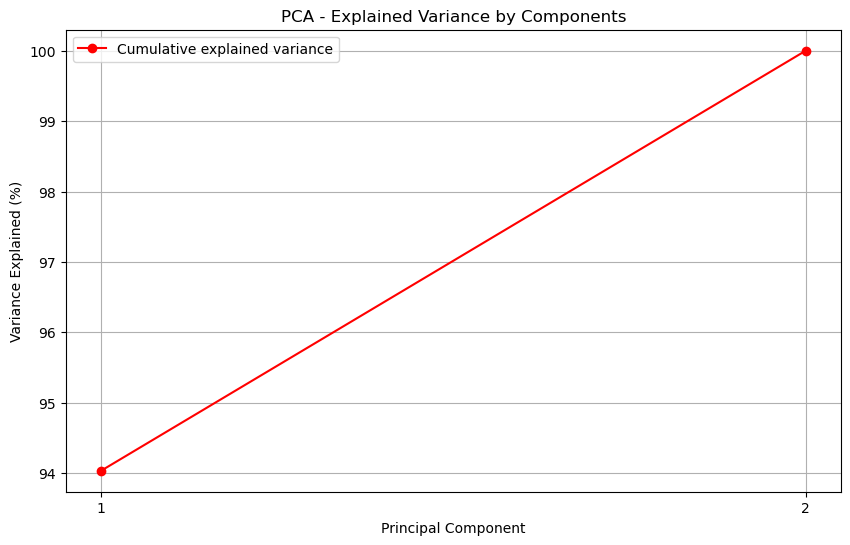

In [37]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

In [38]:
pca.components_

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

In [39]:
X_pca = PCA(n_components=1).fit_transform(X_pca_fit)
pca_df = pd.DataFrame(X_pca, columns=["VW_PC1"], index=engineered_df.index)
pca_df.head()

,VW_PC1
0,0.918978
1,0.533468
2,0.244641
3,-0.025467
4,-0.281085


In [40]:
engineered_df = pd.concat([engineered_df, pca_df], axis=1)
engineered_df.head()

,Timestamp,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,...,doy,year,shifted_doy,Ag_year,in_season,GDD_in_season,cumulative_GDD,Growth_Stage,root_weighted_soil_moisture,VW_PC1
0,2018-01-01,0.371225,0.394800,0.302474,0.270380,294.466628,294.026363,293.144239,290.955942,293.314439,...,1,2018,67,2017,1,10.006207,10.006207,SoS,0.0,0.918978
1,2018-01-02,0.347555,0.379907,0.302010,0.270373,293.848773,293.884632,293.162249,290.987094,289.883795,...,2,2018,68,2017,1,7.404952,17.411159,SoS,0.0,0.533468
2,2018-01-03,0.330737,0.367946,0.301465,0.270366,293.911082,293.727159,293.150462,291.017846,290.475579,...,3,2018,69,2017,1,7.165753,24.576912,SoS,0.0,0.244641
3,2018-01-04,0.315402,0.356416,0.300741,0.270358,294.503247,293.925443,293.141661,291.047929,291.254956,...,4,2018,70,2017,1,8.108309,32.685221,SoS,0.0,-0.025467
4,2018-01-05,0.302094,0.344448,0.299777,0.270349,295.542367,294.539959,293.180125,291.077664,293.653434,...,5,2018,71,2017,1,10.420760,43.105980,SoS,0.0,-0.281085


### Soil Temperature Layers

Soil temperatures at layers 1 and 2 are highly volatile, with swings typically mirroring the current surface weather exactly. The deeper soil temperatures are hardly effected by the diurnal temperature, meaning that the daily weather is entirely erased by the time we reach 100-289cm. We again consider PCA for these 4 layers.

In [41]:
prefix = "soil_temperature_level"
layers = range(1, 5)

In [42]:
st_df = engineered_df[[f"{prefix}_{l}" for l in layers]].copy()
st_df[["Growth_Stage", "shifted_doy", "Timestamp"]] = engineered_df[["Growth_Stage", "shifted_doy", "Timestamp"]].copy()
st_df.head()

,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,Growth_Stage,shifted_doy,Timestamp
0,294.466628,294.026363,293.144239,290.955942,SoS,67,2018-01-01
1,293.848773,293.884632,293.162249,290.987094,SoS,68,2018-01-02
2,293.911082,293.727159,293.150462,291.017846,SoS,69,2018-01-03
3,294.503247,293.925443,293.141661,291.047929,SoS,70,2018-01-04
4,295.542367,294.539959,293.180125,291.077664,SoS,71,2018-01-05


#### 1. Shallow Mean

In [43]:
layers = range(1, 4) # layers 1 to 3
engineered_df["Shallow_mean"] = st_df[[f"{prefix}_{l}" for l in layers]].mean(axis=1)
engineered_df["Shallow_mean"].head()

0    293.879077
1    293.631885
2    293.596234
3    293.856784
4    294.420817
Name: Shallow_mean, dtype: float64

#### 2. Principal Component Analysis
To justify the use of PCA for `soil_temperature_level_1` through `soil_temperature_level_4`, we must first prove that there exists significant multicolinearity between the predictors. 

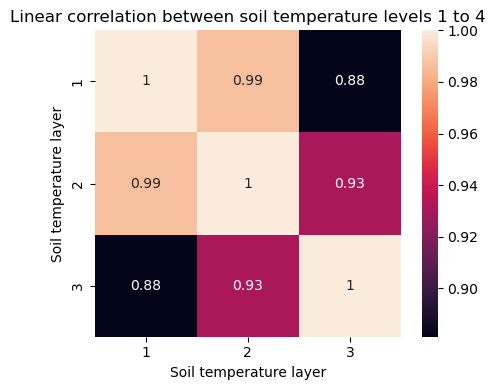

In [44]:
corr = st_df[[f"{prefix}_{l}" for l in layers]].corr()

plt.figure(figsize=(5,4))
plt.title("Linear correlation between soil temperature levels 1 to 4")

sns.heatmap(corr, xticklabels=layers, yticklabels=layers, annot=True, square=True)
plt.xlabel("Soil temperature layer")
plt.ylabel("Soil temperature layer")

plt.tight_layout()
plt.show()

There is high correlation between layers 1 and 3, moderate correlation between layers 3 and 4, and slight correlation between layers 1 and 2, and 4. We start by first fitting PCA on all 4 variables:

In [45]:
layers = range(1, 5)
stanscal = StandardScaler()

X = st_df[[f"{prefix}_{l}" for l in layers]]
X_pca_fit = stanscal.fit_transform(X)

In [46]:
pca = PCA()
pca.fit(X_pca_fit)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

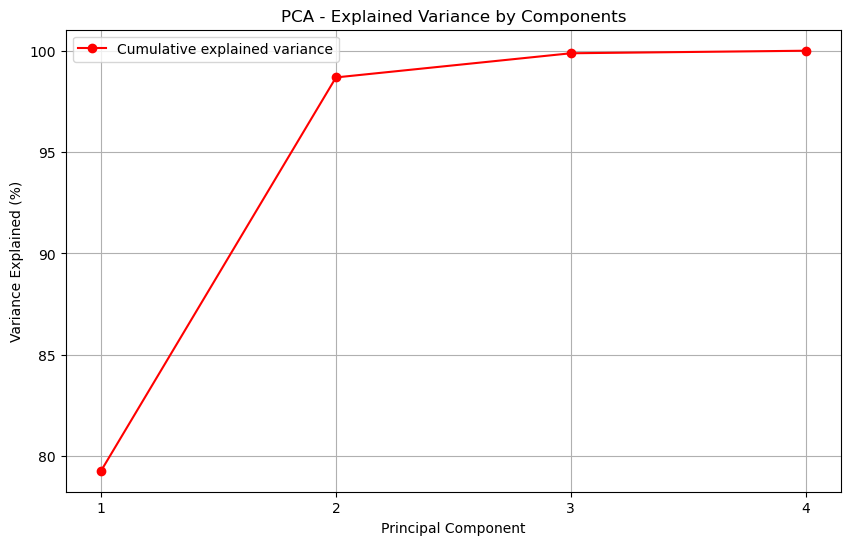

In [47]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

In [48]:
pca.components_

array([[ 0.52588674,  0.5428852 ,  0.55216453,  0.35189931],
       [-0.37201523, -0.28265153,  0.07053473,  0.8813272 ],
       [-0.54353841, -0.06187289,  0.77700072, -0.31146046],
       [-0.53815778,  0.78838792, -0.29395418,  0.04921003]])

The fact that 2 principal components explains almost 100% of the variance shows that these 4 predictors are in actuality just in 2 dimensional space. Additionally, the loadings of the first principal component suggest that direction explains the overall soil warmth, while the loadings of the second suggest that direction explains the difference in temperature between the shallow levels and the deeper levels.

This is all well and good but something that still stands out in our correlation matrix is the fact that layers 1 through 3 are highly correlated ($\rho = 0.88 \ - \ 0.99$). This could suggest that they all pretty much explain the same thing and are highly redundant - and that "thing" could be summarised most concretely by projecting all 3 layers down to a single dimension. 

In [49]:
layers = range(1, 4)
stanscal = StandardScaler()

X = st_df[[f"{prefix}_{l}" for l in layers]]
X_pca_fit = stanscal.fit_transform(X)

In [50]:
pca = PCA()
pca.fit(X_pca_fit)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

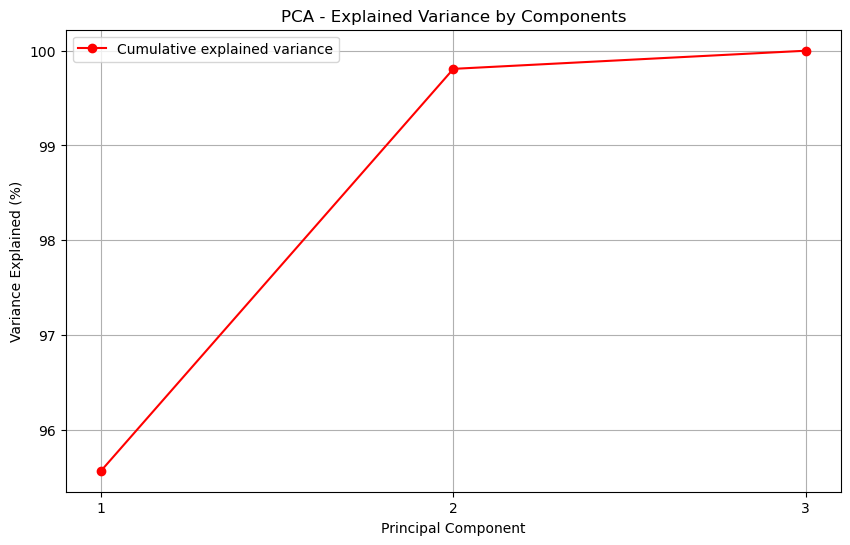

In [51]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

In [52]:
pca.components_

array([[ 0.57784257,  0.58786826,  0.56613503],
       [-0.56563532, -0.21159255,  0.79704785],
       [-0.58834909,  0.78079415, -0.21025187]])

Indeed, one principal component explains $\sim 95\%$ of the common variation of the data in layers 1 to 3. This is a significant reduction in dimension and will almost certainly contribute to the elimination of multicolinearity. Keeping layer 4 as separate still allows for the analysis of the thermal behaviour of the deeper levels in a separate, uncorrelated feature.

In [53]:
X_pca = PCA(n_components=1).fit_transform(X_pca_fit)
pca_df = pd.DataFrame(X_pca, columns=["ST_PC1"], index=engineered_df.index)
pca_df.head()

,ST_PC1
0,1.550109
1,1.465590
2,1.450933
3,1.541121
4,1.741368


In [54]:
engineered_df = pd.concat([engineered_df, pca_df], axis=1)
engineered_df.head()

,Timestamp,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,...,shifted_doy,Ag_year,in_season,GDD_in_season,cumulative_GDD,Growth_Stage,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1
0,2018-01-01,0.371225,0.394800,0.302474,0.270380,294.466628,294.026363,293.144239,290.955942,293.314439,...,67,2017,1,10.006207,10.006207,SoS,0.0,0.918978,293.879077,1.550109
1,2018-01-02,0.347555,0.379907,0.302010,0.270373,293.848773,293.884632,293.162249,290.987094,289.883795,...,68,2017,1,7.404952,17.411159,SoS,0.0,0.533468,293.631885,1.465590
2,2018-01-03,0.330737,0.367946,0.301465,0.270366,293.911082,293.727159,293.150462,291.017846,290.475579,...,69,2017,1,7.165753,24.576912,SoS,0.0,0.244641,293.596234,1.450933
3,2018-01-04,0.315402,0.356416,0.300741,0.270358,294.503247,293.925443,293.141661,291.047929,291.254956,...,70,2017,1,8.108309,32.685221,SoS,0.0,-0.025467,293.856784,1.541121
4,2018-01-05,0.302094,0.344448,0.299777,0.270349,295.542367,294.539959,293.180125,291.077664,293.653434,...,71,2017,1,10.420760,43.105980,SoS,0.0,-0.281085,294.420817,1.741368


Of course, PCA makes an assumption of independence between observations. This is definitely not rooted in reality since soil temperature is inherently a temporal variable, so the value of the predictor at time step $t$ is very much determined by that at $t-1$. We will see if this is a deal breaker for the feature when we fit the model.



---

## Lagging and Rolling

In [55]:
from features import engineering

Our final approach to feature engineering is  **lagging** variables (i.e. moving the corresponding observations of a predictor forward in time to align with a timestamp in the future) and **rolling** variables (statistics calculated over a set time period). Instead of just arbitrarly lagging and rolling each available predictor, we will use only some of our original and engineered features to avoid exploding feature counts.

In [56]:
periods = [1, 7, 30]
cols = [
    "temperature_2m", 
    "surface_solar_radiation_downwards_sum", 
    "precipitation", 
    "root_weighted_soil_moisture", 
    "volumetric_soil_water_layer_3",
    "volumetric_soil_water_layer_4",
    "soil_temperature_level_4",
    "VW_PC1", 
    "ST_PC1", 
    "Shallow_mean"
]

In [57]:
lag_df = engineering.lag_col(engineered_df, cols, periods)
roll_df = engineering.roll_cols(engineered_df, cols, periods)
roll_lag_df = pd.merge(lag_df, roll_df, on="Timestamp")
roll_lag_df["in_season"] = engineered_df["in_season"].copy()
roll_lag_df.head()

,Timestamp,temperature_2m_lag_1,temperature_2m_lag_7,temperature_2m_lag_30,surface_solar_radiation_downwards_sum_lag_1,surface_solar_radiation_downwards_sum_lag_7,surface_solar_radiation_downwards_sum_lag_30,precipitation_lag_1,precipitation_lag_7,precipitation_lag_30,...,ST_PC1_7D_sum,ST_PC1_30D_mean,ST_PC1_30D_sum,Shallow_mean_1D_mean,Shallow_mean_1D_sum,Shallow_mean_7D_mean,Shallow_mean_7D_sum,Shallow_mean_30D_mean,Shallow_mean_30D_sum,in_season
0,2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,293.879077,293.879077,NaN,NaN,NaN,NaN,1
1,2018-01-02,293.314439,NaN,NaN,3.288490e+07,NaN,NaN,0.000000,NaN,NaN,...,NaN,NaN,NaN,293.631885,293.631885,NaN,NaN,NaN,NaN,1
2,2018-01-03,289.883795,NaN,NaN,3.127135e+07,NaN,NaN,0.000000,NaN,NaN,...,NaN,NaN,NaN,293.596234,293.596234,NaN,NaN,NaN,NaN,1
3,2018-01-04,290.475579,NaN,NaN,2.872766e+07,NaN,NaN,0.000000,NaN,NaN,...,NaN,NaN,NaN,293.856784,293.856784,NaN,NaN,NaN,NaN,1
4,2018-01-05,291.254956,NaN,NaN,3.154392e+07,NaN,NaN,2.618651,NaN,NaN,...,NaN,NaN,NaN,294.420817,294.420817,NaN,NaN,NaN,NaN,1


In [58]:
roll_lag_df.shape

(2921, 92)

Rolling and lagging variables like this introduces high feature counts which makes it quite difficult to find out which one of these truly contribute positively to the seasonal behaviour of our crops (and as such, contribute to finding anomalies in the data). 

Due to this being an unsupervised learning problem where the "stress" state of a crop is inherently hidden, figuring out which of these rolled/lagged features are important is left for the model building phase.

## Summary

In [59]:
engineered_df.to_csv("../data/processed/eng_non_spectral_df.csv")
roll_lag_df.to_csv("../data/processed/roll_lag_df.csv")